# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [2]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [3]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [4]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [5]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [6]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [7]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [8]:
x_train_bias = torch.FloatTensor(x_train_bias) # etapa obrigatória
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


In [10]:
print(x_train_bias)

tensor([[1.0000, 1.0000],
        [1.0000, 0.7143],
        [1.0000, 0.9524],
        [1.0000, 0.2857],
        [1.0000, 0.7619],
        [1.0000, 0.3810],
        [1.0000, 0.6667],
        [1.0000, 0.0000],
        [1.0000, 0.8095],
        [1.0000, 0.1429],
        [1.0000, 0.0476],
        [1.0000, 0.4762],
        [1.0000, 0.5238],
        [1.0000, 0.5714],
        [1.0000, 0.3333],
        [1.0000, 0.8571],
        [1.0000, 0.3333],
        [1.0000, 0.4286],
        [1.0000, 0.6190],
        [1.0000, 0.3333],
        [1.0000, 0.4762],
        [1.0000, 0.5714],
        [1.0000, 0.6667],
        [1.0000, 0.5714],
        [1.0000, 0.7143],
        [1.0000, 0.8095],
        [1.0000, 0.9048],
        [1.0000, 0.8571],
        [1.0000, 0.5238],
        [1.0000, 0.3810],
        [1.0000, 0.2857],
        [1.0000, 0.2857],
        [1.0000, 0.4286],
        [1.0000, 0.5238],
        [1.0000, 0.2381],
        [1.0000, 0.5238],
        [1.0000, 0.8571],
        [1.0000, 0.6667],
        [1.0

## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [11]:
#Inicialização usando toch.nn.Linear

model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [12]:
model.weight.data

tensor([[-0.6661, -0.1387]])

In [13]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipykernel_5775/2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [14]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [16]:
model(xx)

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

In [17]:
model(x_train_bias)

tensor([[-0.0747],
        [-0.0671],
        [-0.0734],
        [-0.0557],
        [-0.0684],
        [-0.0582],
        [-0.0658],
        [-0.0480],
        [-0.0696],
        [-0.0518],
        [-0.0493],
        [-0.0607],
        [-0.0620],
        [-0.0633],
        [-0.0569],
        [-0.0709],
        [-0.0569],
        [-0.0595],
        [-0.0645],
        [-0.0569],
        [-0.0607],
        [-0.0633],
        [-0.0658],
        [-0.0633],
        [-0.0671],
        [-0.0696],
        [-0.0722],
        [-0.0709],
        [-0.0620],
        [-0.0582],
        [-0.0557],
        [-0.0557],
        [-0.0595],
        [-0.0620],
        [-0.0544],
        [-0.0620],
        [-0.0709],
        [-0.0658],
        [-0.0569],
        [-0.0557],
        [-0.0557],
        [-0.0633],
        [-0.0595],
        [-0.0493],
        [-0.0569],
        [-0.0582],
        [-0.0582],
        [-0.0645],
        [-0.0506],
        [-0.0582]], grad_fn=<MmBackward0>)

## Treinamento

In [18]:
num_epochs = 100
learning_rate = 0.5
for epoch in range(num_epochs):
    #inputs = Variable(x_train_bias)
    #target = Variable(y_train)
    inputs = x_train_bias
    target = y_train

    # forward - predict
    y_pred = model(inputs)

    #loss cálculo da função de perda
    loss = torch.mean((y_pred - target)**2)

    # backward propagation - cálculo gradient
    loss.backward()

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.data))

Epoch[20/100], loss: 0.022983
Epoch[40/100], loss: 0.021432
Epoch[60/100], loss: 0.021207
Epoch[80/100], loss: 0.021175
Epoch[100/100], loss: 0.021170


## Avaliação

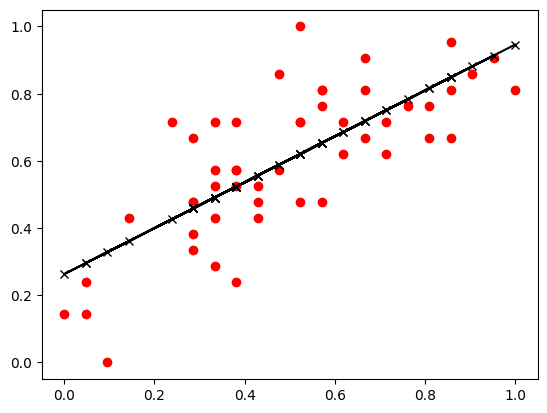

In [19]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Acessando os parâmetros

In [20]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2631, 0.6830]]))])

### Parâmetros ótimos, solução analítica

In [21]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data`? Por que precisa do `data`?
   

R: A loss é um tensor do PyTorch com requires_grad=True, ou seja, ele guarda toda a informação do grafo computacional usada para calcular os gradientes automaticamente. Quando usamos loss.data, estamos pegando só o valor numérico da perda, sem esse grafo.
Isso já é suficiente quando queremos apenas imprimir ou registrar o valor da loss. Até daria para usar loss direto no print, mas usar loss.data deixa mais claro que a gente só quer o número e ajuda a evitar manter o grafo em memória sem necessidade.

- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

In [22]:
# Predict com os pesos já treinados
y_pred_trained = model(x_train_bias)213

# Cálculo do MSE
loss_trained = torch.mean((y_pred_trained - y_train) ** 2)

print(f'Perda (MSE) com pesos treinados: {loss_trained.data:.6f}')

Perda (MSE) com pesos treinados: 0.021170


- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos
   parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.

In [25]:
model.weight.data = torch.zeros(1, 2)
torch.nn.init.uniform_(model.weight.data, -0.1, 0.1)

w0_list = []
w1_list = []

num_epochs = 100
learning_rate = 0.5

for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    y_pred = model(inputs)
    loss = torch.mean((y_pred - target) ** 2)
    loss.backward()

    w0_list.append(model.weight.data[0, 0].item())
    w1_list.append(model.weight.data[0, 1].item())

    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data
    model.weight.grad.data.zero_()

    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'.format(epoch+1, num_epochs, loss.data))

# Solução analítica
x_bias = x_train_bias
y = y_train
w_opt = (torch.inverse(x_bias.t().mm(x_bias)).mm(x_bias.t())).mm(y)
w0_opt = w_opt[0].item()
w1_opt = w_opt[1].item()


Epoch[20/100], loss: 0.023325
Epoch[40/100], loss: 0.021482
Epoch[60/100], loss: 0.021215
Epoch[80/100], loss: 0.021176
Epoch[100/100], loss: 0.021170


## Ploting vectors

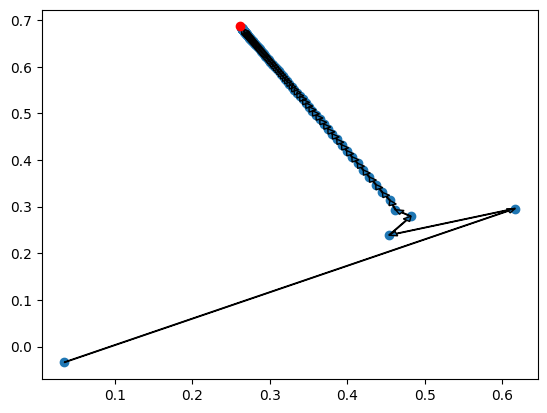

In [26]:
plt.scatter(w0_list, w1_list)
w0_old = None
for (w0, w1) in zip(w0_list, w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0 - w0_old, w1 - w1_old,
                  head_length=0.01, head_width=0.01, shape='full',
                  length_includes_head=True)
    w0_old, w1_old = w0, w1

# Apenas marca o ponto ótimo em vermelho
plt.scatter([w0_opt], [w1_opt], color='red')

plt.show()

# Aprendizados

Neste notebook, os principais aprendizados e conceitos demonstrados são:

*   **Regressão Linear com PyTorch**: Como implementar um modelo de regressão linear para prever o comprimento de sépalas a partir do comprimento de pétalas usando a biblioteca PyTorch.
*   **Preparação e Normalização de Dados**: A importância de carregar, pré-processar (selecionando features específicas do dataset Iris) e normalizar os dados para otimizar o treinamento do modelo.
*   **Adição de Bias**: A técnica de adicionar uma coluna de '1's aos dados de entrada para incluir o termo de bias (`intercept`) diretamente na matriz de pesos do modelo linear, permitindo que `nn.Linear` seja usado sem o `bias` intrínseco.
*   **Definição do Modelo `nn.Linear`**: Utilização da classe `torch.nn.Linear` para criar a camada linear, especificando o número de features de entrada e saída. A desativação explícita do `bias` na camada (`bias=False`) devido à inclusão manual do bias nos dados.
*   **Inicialização de Pesos**: Como inspecionar e inicializar os pesos do modelo (`model.weight.data`) usando funções como `torch.nn.init.uniform_`.
*   **Ciclo de Treinamento Manual**: Implementação passo a passo do ciclo de treinamento de uma rede neural:
    *   **Forward Pass**: Realizando previsões (`y_pred = model(inputs)`).
    *   **Cálculo da Função de Perda (MSE)**: Utilizando o erro quadrático médio (`torch.mean((y_pred - target)**2)`) como métrica de otimização.
    *   **Backward Pass**: O uso de `loss.backward()` para calcular automaticamente os gradientes dos pesos em relação à perda, aproveitando o autograd do PyTorch.
    *   **Atualização Manual dos Pesos**: A aplicação do algoritmo de Gradiente Descendente para atualizar os pesos do modelo (`model.weight.data = model.weight.data - learning_rate * model.weight.grad.data`).
    *   **Zeroing dos Gradientes**: A necessidade de zerar os gradientes (`model.weight.grad.data.zero_()`) após cada iteração para evitar acumulação indesejada.
*   **Avaliação do Modelo**: Visualização gráfica dos dados originais e da linha de regressão ajustada pelo modelo para avaliar seu desempenho.
*   **Comparação com Solução Analítica**: Demonstração de como obter a solução ótima para os pesos de um modelo de regressão linear (equação normal) e a comparação desses pesos com os pesos aprendidos via Gradiente Descendente, validando a abordagem de treinamento.
*   **Análise da Evolução dos Parâmetros**: Acompanhamento e visualização da trajetória dos pesos do modelo durante o treinamento em um gráfico, mostrando como eles convergem para a solução ótima.